# Time in Treatment: 
### Tracking Treatment Duration Through a 2025 Facility Reorganization

##### This analysis will explore how a organizational re-structuring in August 2025 affected the length of stay at a Substance Use Treatment facility in Minnesota. 

Sections:
1. Data Cleaning & Preparation
2. Categorical Exploration
3. Permutation Testing

Time Frame of Analysis:
 - **March 2025 - Feburary 2026**

## Data Cleaning & Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
los = pd.read_excel("Length of Stay Data.xlsx")

# Set random seed for reproducibility
np.random.seed(42)

### 1. Convert columns and standardize strings
   - Columns in the Length of Stay Data excel spreadsheet:

     - **Subject_ID:** Each client was pre-assigned a number 1-307
  
     - **Program:** Contains the string "Womens Residental Treatment" on every entry (will be dropped)
  
     - **Admission_Date:** the date the treatment episode started
  
     - **Date_of_Discharge:** the date the treatment episode ended
  
     - **Reason_for_Discharge:** includes the reason the client exited the program

In [3]:
los.head(5)

,Subject_ID,Program,Admission_Date,Date_of_Discharge,Reason_for_Discharge
0,1,Women's Residential Treatment Center,2026-03-04,2026-03-04,Patient left without staff approval
1,2,Women's Residential Treatment Center,2025-03-24,2025-04-14,Patient conduct (behavioral)
2,3,Women's Residential Treatment Center,2025-06-16,2025-06-18,Patient left without staff approval
3,3,Women's Residential Treatment Center,2025-08-08,2025-08-13,Patient conduct (behavioral)
4,4,Women's Residential Treatment Center,2025-09-11,2025-09-12,Assessed as inappropriate


In [4]:
# column conversion
los['Subject_ID'] = pd.to_numeric(los['Subject_ID'], errors='coerce')
los =  los.drop('Program', axis=1)
los['Admission_Date'] = pd.to_datetime(los['Admission_Date'], errors='coerce')
los['Date_of_Discharge'] = pd.to_datetime(los['Date_of_Discharge'], errors='coerce')
los['Reason_for_Discharge'] = los['Reason_for_Discharge'].astype('str')

# standardize strings
string_col = los.select_dtypes(include=['string'])
column_list = string_col.columns.to_list()
los[column_list] = los[column_list].apply(lambda x: x.str.lower())

### 2. Apply Filters
   
   - **Date_of_Discharge** is filtered to include clients who discharged after March 1st 2025 and before end of February 2026 
  
   - **Reason_for_Discharge** includes the discharge types relevant for analysis:
       * *Completed Program*   -  the client has completed all program requirements
       * *Patient left without staff approval*     -   the client chooses to leave the program
       * *Patient conduct (behavioral)*   -   the client has created an unsafe environment for others in the program

In [5]:
#filter discharge date
discharged_filter = los['Date_of_Discharge'].between('2025-03-01', '2026-02-28') #6 month periods
los = los[discharged_filter]
print(los['Date_of_Discharge'].min(), los['Date_of_Discharge'].max())

# filter discharge reason
target_strings = ['completed program', 'patient left without staff approval', 'patient conduct (behavioral)']
los = los[los['Reason_for_Discharge'].isin(target_strings)]
los['Reason_for_Discharge'].value_counts()


2025-03-03 00:00:00 2026-02-27 00:00:00


Reason_for_Discharge
patient left without staff approval    119
completed program                       70
patient conduct (behavioral)            54
Name: count, dtype: int64

### 3. Create Columns
 - **Length_of_Stay:** the date of discharge is subtracted from the date of admission for each treatment episode and one is added to the result. This is done in the residential treatment setting as the client receives services the day they arrive on site.
  
 - **Period:** if the discharge date occurs before August 31st, it is put into the *before re-org* category. The *after re-org* category represents treatment episodes that ended after the re-organization.
  
 - **Discharge_Cat:** assigned based on discharge type
   - *successful* - episodes that resulted in program completion
   - *unsucessful* - episodes that ended with the patient leaving against staff advice or due to patient conduct

In [6]:
# create length of stay column
los['Length_of_Stay'] = (los['Date_of_Discharge'] - los['Admission_Date']).dt.days + 1

#create before and after period categories
los['Period'] = los['Date_of_Discharge'].apply(lambda x: 'before re-org' if x < pd.to_datetime('2025-08-31') else 'after re-org')
los['Period'] = los['Period'].astype('category')
print(los['Period'].value_counts())
print("")

#create discharge type categories (successful vs unsuccessful)
def discharge_type(reason):
    if reason == 'completed program':
        return 'successful'
    else:
        return 'unsuccessful'
    
los['Discharge_Cat'] = los['Reason_for_Discharge'].apply(discharge_type)
los['Discharge_Cat'] = los['Discharge_Cat'].astype('category')
print(los['Discharge_Cat'].value_counts())
los.head(5)

Period
after re-org     140
before re-org    103
Name: count, dtype: int64

Discharge_Cat
unsuccessful    173
successful       70
Name: count, dtype: int64


,Subject_ID,Admission_Date,Date_of_Discharge,Reason_for_Discharge,Length_of_Stay,Period,Discharge_Cat
1,2,2025-03-24,2025-04-14,patient conduct (behavioral),22,before re-org,unsuccessful
2,3,2025-06-16,2025-06-18,patient left without staff approval,3,before re-org,unsuccessful
3,3,2025-08-08,2025-08-13,patient conduct (behavioral),6,before re-org,unsuccessful
6,6,2026-02-04,2026-02-05,patient left without staff approval,2,after re-org,unsuccessful
7,7,2025-04-07,2025-06-05,completed program,60,before re-org,successful


# Exploring Categorical Variables

### 1. Period Breakdown
Comparison of the 6 month period before the re-organziation (*before re-org*) verses the 6 month period after the re-organization (*after re-org*). 

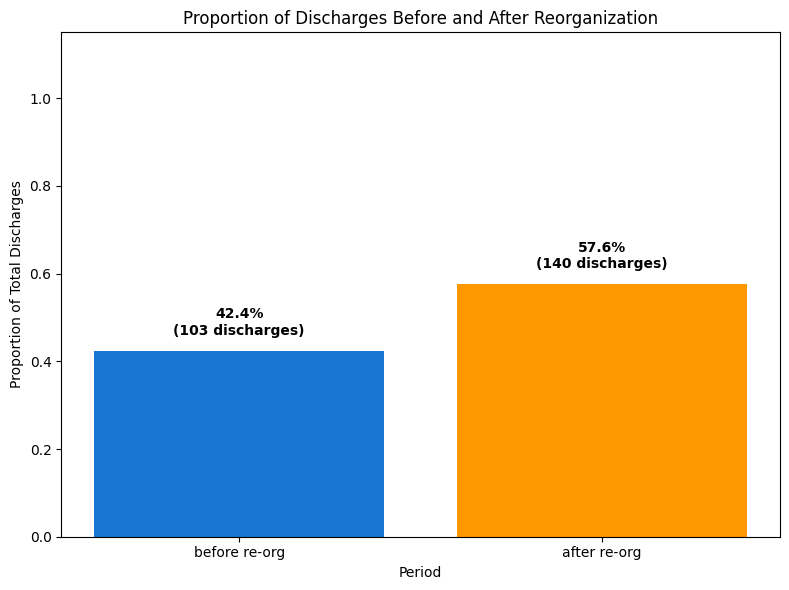

In [7]:
# proportion bar chart for before vs after discharges
period_counts = los['Period'].value_counts(normalize=True).reindex(['before re-org', 'after re-org']).fillna(0)
period_counts_n = los['Period'].value_counts().reindex(['before re-org', 'after re-org']).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(period_counts.index, period_counts.values, color=['#1976D2', '#FF9800'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Proportion of Total Discharges')
ax.set_xlabel('Period')
ax.set_title('Proportion of Discharges Before and After Reorganization')

for i, (prop, count) in enumerate(zip(period_counts.values, period_counts_n.values)):
    ax.text(i, prop + 0.03, f'{prop:.1%}\n({count} discharges)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

The period after the re-organization had a greater proportion of discharges compared to the period before the re-organization. These results were expected as staff and program leadership have noticed an increase in discharge rates in the months following the re-organization. 

Now, let's compare the proportion of successful and unsuccessful discharges between the two periods:

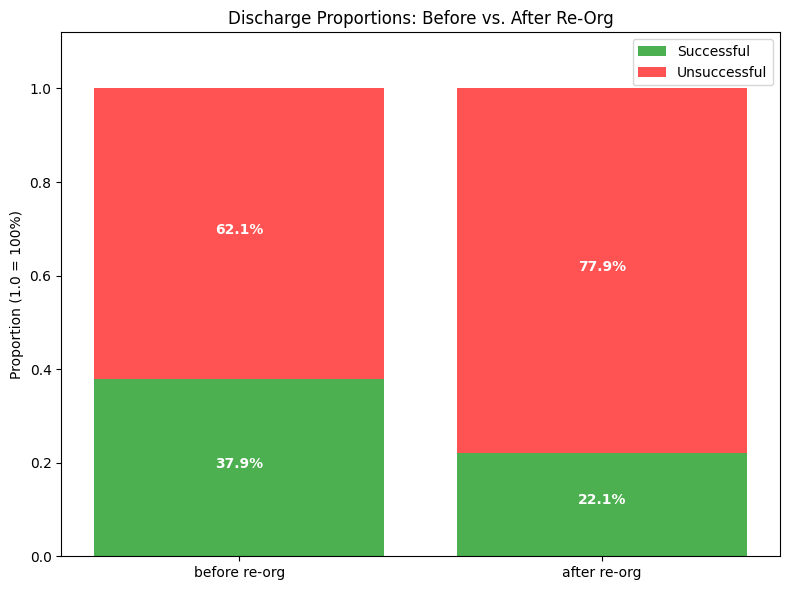

In [8]:
#successful vs unsuccessful

# calculate porportions of successful vs unsuccessful discharges for both periods
before_props = los[los['Period'] == 'before re-org']['Discharge_Cat'].value_counts(normalize=True)
after_props = los[los['Period'] == 'after re-org']['Discharge_Cat'].value_counts(normalize=True)

# prepare data for plot
periods = ['before re-org', 'after re-org']
success_vals = [before_props.get('successful', 0), after_props.get('successful', 0)]
unsuccess_vals = [before_props.get('unsuccessful', 0), after_props.get('unsuccessful', 0)]

# create plot
fig, ax = plt.subplots(figsize=(8, 6))

# plot successes
ax.bar(periods, success_vals, label='Successful', color='#4CAF50')

# plot unsuccessful discharges on top of successes
ax.bar(periods, unsuccess_vals, bottom=success_vals, label='Unsuccessful', color='#FF5252')

# formatting
ax.set_ylabel('Proportion (1.0 = 100%)')
ax.set_title('Discharge Proportions: Before vs. After Re-Org')
ax.set_ylim(0, 1.12)  # buffer for the legend
ax.legend()

# add percentage text on the bars
for i in range(len(periods)):
    # label for Successful
    ax.text(i, success_vals[i]/2, f'{success_vals[i]:.1%}', 
            ha='center', color='white', fontweight='bold')
    # label for Unsuccessful
    ax.text(i, success_vals[i] + (unsuccess_vals[i]/2), f'{unsuccess_vals[i]:.1%}', 
            ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

The proportion of successful discharges dropped from 37.9% to 22.1% after the re-organization. 

Not only did the amount of discharges increase, the proportion of unsuccessful discharges increased after the re-organization. 

### 2. Length of Stay

The primary metric for this analysis is the length of stay. This is the number of days that the client was on site and receiving treatment. 

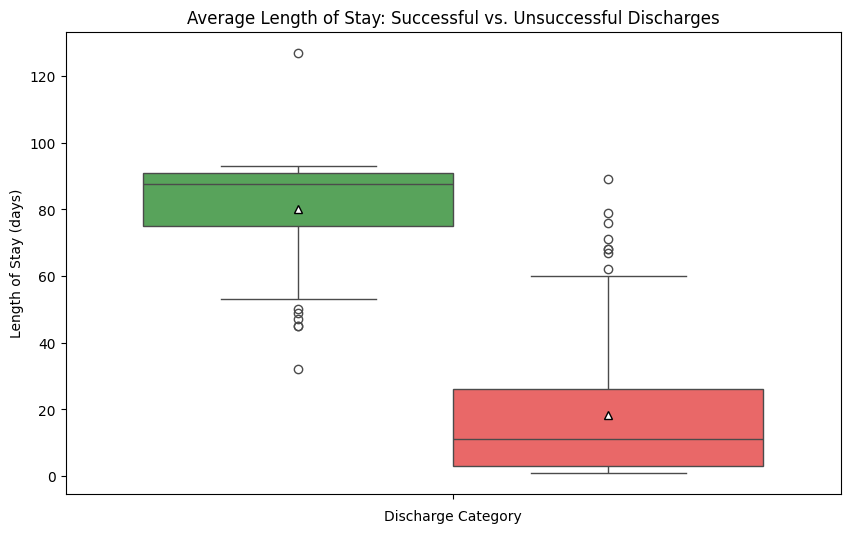

In [9]:
#average length of stay before for successful vs unsuccessful discharges
stats_df2 = los.groupby('Discharge_Cat')['Length_of_Stay'].agg(['mean', 'median'])

my_palette2 = ['#4CAF50', '#FF5252']

plt.figure(figsize=(10, 6))

ax = sns.boxplot(data=los, hue='Discharge_Cat', y='Length_of_Stay', 
                 showmeans=True,
                 meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black"},
                 palette=my_palette2,
                 legend=False)

plt.title('Average Length of Stay: Successful vs. Unsuccessful Discharges')
plt.xlabel('Discharge Category')
plt.ylabel('Length of Stay (days)')


plt.show()

The overall average length of stay for successful discharges is 80, while the median length of stay is 88. There is a left skew in the length of stay distribution for successful discharge types. This is expected, as the Women's Treatment Center follows a 90 day treatment plan, however the actual length of stay for successful discharges is determined by the client's progress. Some may hit their goals early, and some may need more time to graduate. The left skew may be exaggerated by a treatment episode that lasted 127 days.

 Let's filter that outlier out to see how the mean and median changes:

In [10]:
los_filtered = los[los['Length_of_Stay'] <= 100]

stats_df3 = los_filtered.groupby('Discharge_Cat')['Length_of_Stay'].agg(['mean', 'median'])

print(stats_df3)

                    mean  median
Discharge_Cat                   
successful     79.405797    87.0
unsuccessful   18.410405    11.0


The mean and median length of stay for successful discharges decreased by 1 when the outlier was removed. This isn't a major difference, and keeping the outlier point in the analysis is appropriate in this case as this is a natural variation in length of treatment. 

For unsuccessful discharges, the mean (18 days) is greater than the median (11 days). This indicates a right skew for the distribution of unsuccessful discharges. This is an expected result as this category includes clients that left the program before completion.

### 3. Length of Stay by Period

Next, the distribution of length of stay is created for both periods and compared. 

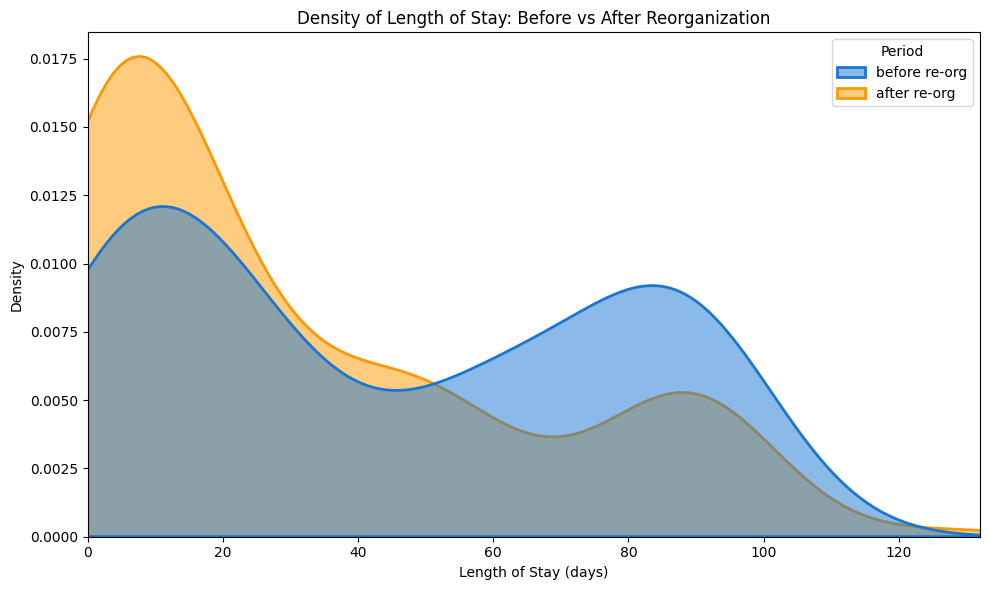

In [11]:
period_order = ['before re-org', 'after re-org']

#define color mapping for the periods
custom_palette = {
    'before re-org': '#1976D2', 
    'after re-org': '#FF9800'
}

plt.figure(figsize=(10, 6))
sns.kdeplot(data=los, x='Length_of_Stay', hue='Period', 
            hue_order=period_order,
            fill=True, common_norm=False, alpha=0.5, linewidth=2,
            palette=custom_palette)
plt.title('Density of Length of Stay: Before vs After Reorganization')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Density')
plt.xlim(0, los['Length_of_Stay'].max() + 5)
plt.tight_layout()
plt.show()

In the period before the reorganization, the distribution of length of stay is bimodal. Discharges are clustered around the the average lenth of stay for successful (88 days) and unsuccessful (18 days) discharge types. 

The 'after re-org' distribution is more unimodal, however there is a significant right skew. There were more discharges occuring eariler stage of treatment in the period after the re-organization compared to before. There are also less clients making to the later stage of treatment. 

Let's stratify the density plots to take a closer look at the length of stay by discharge type:

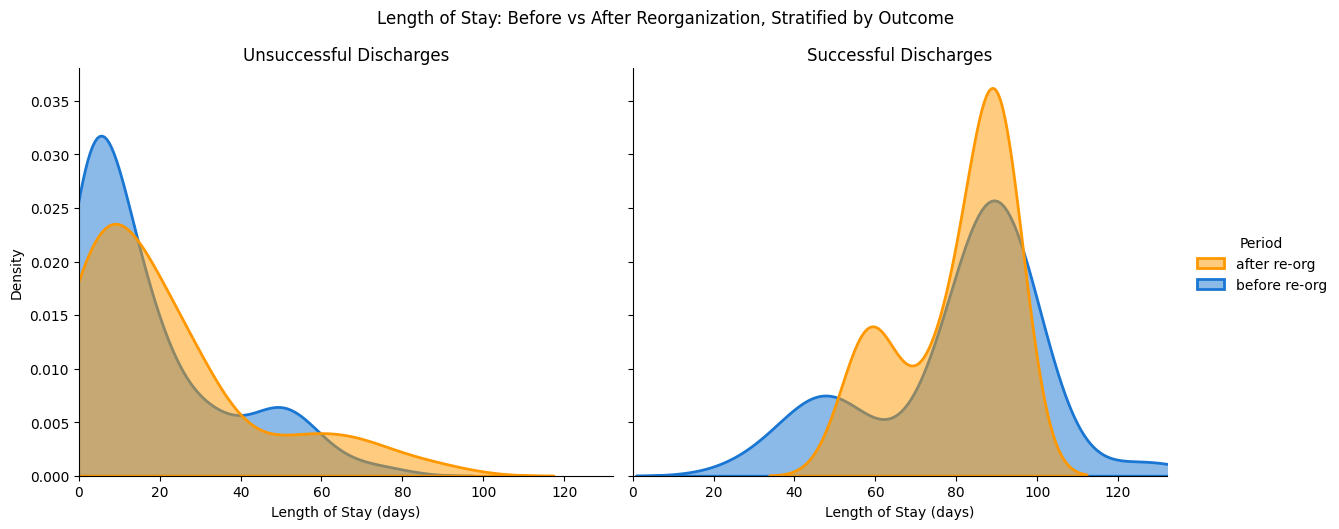

In [12]:
# faceted density plot

g = sns.displot(
    data=los, 
    x='Length_of_Stay', 
    hue='Period',            # Colors the lines by Before vs. After Re-org
    col='Discharge_Cat',    # Creates side-by-side charts for Successful vs. Unsuccessful
    col_order=['successful', 'unsuccessful'],
    palette=custom_palette,
    kind='kde',              # Density plot
    fill=True, 
    common_norm=False,       # Ensures each distribution is normalized independently
    alpha=0.5, 
    linewidth=2,
    height=5, 
    aspect=1.2
)

g.set_axis_labels("Length of Stay (days)", "Density")

#g.set_titles("{col_name} Discharges") # Automatically titles them based on the column values
# override the titles 
axes = g.axes.flatten()
axes[0].set_title("Unsuccessful Discharges")
axes[1].set_title("Successful Discharges")

g.fig.suptitle('Length of Stay: Before vs After Reorganization, Stratified by Outcome', y=1.05)
g.set(xlim=(0, los['Length_of_Stay'].max() + 5))

plt.show()

Unsuccessful discharges:
 - Both the 'before' and 'after' periods have a primary peak of discharges in the early days of treatment, though they center around slighly different values and differ in height. In the after phase of the re-organization, the distribution is wider towards the later days of treatment. This indicates that there have been more unsuccessful discharges in the later stage of treatment for the period after the re-organizaton. 

Successful discharges:
 - Both primary peaks are centered neatly around the overall median length of stay for successful discharges (88). The distribution for the 'after' period is more clustered around this point compared to the 'before' period. The distribution for the 'before' phase has a more gradual spread, indicating that there was more variability in the length of stay for successful discharges in this period.
 - Note that there is a secondary peak on this distribution for both periods. Every client goes through a diagnostic assessment upon intake that determines the level of care they recieve. There is two tiers: high and low intensity. Typically clients start out in high intensity and progress to low intensity throughout their stay. There is a subset of clients that start out in the low-intensity level of care. For these clients, insurance only covers their treatment for about 40-60 days. 



# Hypothesis Test

For this analysis, a permutation test is used to determine if there is a difference in the mean length of stay for successful/unsuccessful discharges between the period before and after the re-organization. A permutation test is appropriate here because residential treatment episodes are not strictly independent (as some clients return to treatment), and it does not rely on the assumption of normality.

The first set of permutation tests looks at the difference in average length of stay. A second set of permutation tests will look at median length of stay.

To quantify uncertainty, bootstrap confidence intervals were generated for both the mean and the median differences. The Central Limit Theorem (CLT) does not apply to the median, as it is an order statistic rather than a sample average. Therefore, bootstrapping is required to accurately estimate the 95% confidence interval for the difference in median length of stay.

In [13]:
before_subjects = set(los[los['Period'] == 'before re-org']['Subject_ID'])
after_subjects = set(los[los['Period'] == 'after re-org']['Subject_ID'])

both_periods_subjects = before_subjects.intersection(after_subjects)

total_clients = los['Subject_ID'].nunique()
unique_before = len(before_subjects)
unique_after = len(after_subjects)
clients_in_both = len(both_periods_subjects)

print(f"Total unique clients: {total_clients}")
print(f"Unique clients in the Before period: {unique_before}")
print(f"Unique clients in the After period: {unique_after}")
print(f"Clients present in both periods: {clients_in_both}")

Total unique clients: 226
Unique clients in the Before period: 97
Unique clients in the After period: 133
Clients present in both periods: 4


Note that these are grouped permutation tests. Period labels are shuffled by switching up the `Subject_ID.' The approach was taken to ensure that dependent episodes (the outcome of the current episode may have been affected by the client's experiences in the first treatment episode) are preserved throughout the analysis. There are 4 clients that discharged in the "before" period, re-entered treatment, and discharged again in the "after" period. While it would have been simple to exclude these four clients, treatment re-entry is common for substance use treatment and it is good practice to keep this in consideration. 

### Permutation Tests for Mean Difference

First the observed difference in average length of stay is calculated for both successful and unsuccessful discharge types. 

In [14]:
success_mean_before_obs = los[(los['Period'] == 'before re-org') & (los['Discharge_Cat'] == 'successful')]['Length_of_Stay'].mean()
success_mean_after_obs = los[(los['Period'] == 'after re-org') & (los['Discharge_Cat'] == 'successful')]['Length_of_Stay'].mean()
success_mean_diff = np.abs(success_mean_before_obs - success_mean_after_obs)

unsuccess_mean_before_obs = los[(los['Period'] == 'before re-org') & (los['Discharge_Cat'] == 'unsuccessful')]['Length_of_Stay'].mean()
unsuccess_mean_after_obs = los[(los['Period'] == 'after re-org') & (los['Discharge_Cat'] == 'unsuccessful')]['Length_of_Stay'].mean()
unsuccess_mean_diff = np.abs(unsuccess_mean_before_obs - unsuccess_mean_after_obs)

print(f"Mean Length of Stay for Successful Discharges - Before Re-org: {success_mean_before_obs:.0f} days")
print(f"Mean Length of Stay for Successful Discharges - After Re-org: {success_mean_after_obs:.0f} days")
print(f"Difference in Mean Length of Stay for Successful Discharges (After - Before): {success_mean_diff:.0f} days") #rounding to whole days for easier interpretation
print("")
print(f"Mean Length of Stay for Unsuccessful Discharges - Before Re-org: {unsuccess_mean_before_obs:.0f} days")
print(f"Mean Length of Stay for Unsuccessful Discharges - After Re-org: {unsuccess_mean_after_obs:.0f} days")
print(f"Difference in Mean Length of Stay for Unsuccessful Discharges (After - Before): {unsuccess_mean_diff:.0f} days")


Mean Length of Stay for Successful Discharges - Before Re-org: 80 days
Mean Length of Stay for Successful Discharges - After Re-org: 80 days
Difference in Mean Length of Stay for Successful Discharges (After - Before): 0 days

Mean Length of Stay for Unsuccessful Discharges - Before Re-org: 21 days
Mean Length of Stay for Unsuccessful Discharges - After Re-org: 17 days
Difference in Mean Length of Stay for Unsuccessful Discharges (After - Before): 4 days


#### Permutation #1: Mean Difference for Successful Discharges

 - **Null hypothesis:** There is no change in the *average* length of stay for *successful* discharges between the six month period before and after the re-organization
  
 - **Alternative hypothesis:** There is a change in the *average* length of stay for *successful* discharges between the period before and after the re-organization. 
  
 - **Test Statistic:** $$\overline{X}_{\text{before, unsuccessful}} - \overline{X}_{\text{after, unsuccessful}}$$

 - **Simulating Data Under the Null:** Period labels are shuffled across unique subjects to maintain exchangeability and avoid inflating Type I errors due to clustered data.

In [15]:
# Create a DataFrame with unique subjects and their original periods
subject_period = los.groupby('Subject_ID')['Period'].first().reset_index()
unique_subjects = subject_period['Subject_ID'].values
original_periods = subject_period['Period'].values

#Number of permutations
n_iterations = 1000
permuted_diffs1 = [success_mean_diff]

# Permutation test for successful discharges
for i in range(n_iterations):
    # Shuffle the period labels across unique subjects
    shuffled_periods = np.random.permutation(original_periods)
    subject_to_period = dict(zip(unique_subjects, shuffled_periods))
    
    # Map back to the episode-level dataframe
    los_shuffled = los.copy()
    los_shuffled['Permuted_Period'] = los_shuffled['Subject_ID'].map(subject_to_period)
    
    # Calculate permuted means for successful discharges
    mean_before_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'before re-org') & 
        (los_shuffled['Discharge_Cat'] == 'successful')
        ]['Length_of_Stay'].mean()
    
    mean_after_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'after re-org') & 
        (los_shuffled['Discharge_Cat'] == 'successful')
        ]['Length_of_Stay'].mean()
    
    permuted_diffs1.append(mean_before_perm - mean_after_perm)


Observed Mean Difference for Successful Discharges (Before - After): 0.31 days
P-value: 0.945
Estimated Sampling Mean: -0.03
Standard Error of the Difference: 4.08


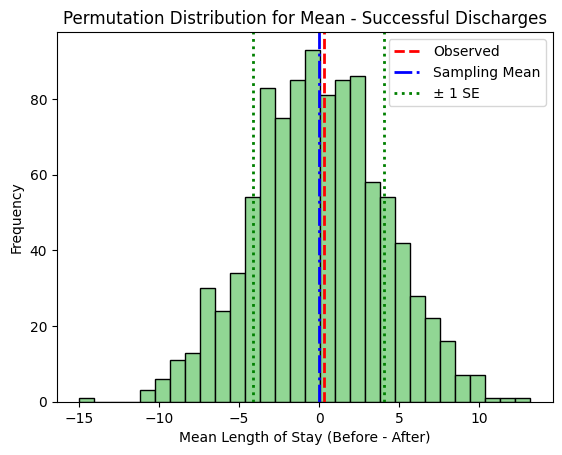

In [16]:
# print observed differences for reference
print(f"Observed Mean Difference for Successful Discharges (Before - After): {success_mean_diff:.2f} days")

# calculate p value for successful discharges
mean_p_value_success = np.mean(np.abs(permuted_diffs1) >= np.abs(success_mean_diff))
print(f"P-value: {mean_p_value_success:.3f}")

# Calculate the mean and standard error from the permuted differences
success_sampling_mean = np.mean(permuted_diffs1)
success_standard_error = np.std(permuted_diffs1, ddof=1) 

print(f"Estimated Sampling Mean: {success_sampling_mean:.2f}")
print(f"Standard Error of the Difference: {success_standard_error:.2f}")

# Plot the histogram
plt.hist(permuted_diffs1, bins=30, edgecolor='black', color='#91D694')

# Observed Difference
plt.axvline(success_mean_diff, color='red', linestyle='--', linewidth=2, label='Observed')

# Estimated Sampling Mean
plt.axvline(success_sampling_mean, color='blue', linestyle='-.', linewidth=2, label='Sampling Mean')

# Standard Error Boundaries
plt.axvline(success_sampling_mean - success_standard_error, color='green', linestyle=':', linewidth=2, label='± 1 SE')
plt.axvline(success_sampling_mean + success_standard_error, color='green', linestyle=':', linewidth=2)

plt.xlabel('Mean Length of Stay (Before - After)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution for Mean - Successful Discharges')
plt.legend()
plt.show()

##### **Analysis for Permutation #1**

 - **Observed Value or Effect:** The observed difference is 0.31 days, indicating that the average length of stay for successful discharges was slightly longer in the before period. 

 - **Reference Distribution:** The reference distribution is represented in a histogram showing how frequent the value representing the difference in average length of stay occurs in the permutation. The observed mean difference for successful discharges falls in the center of the distribution.

 - **p-value:** The p-value for this permutation test is 0.945, meaning that 94% of the differences between the mean length of stay between the before and after period are as or more extreme than the observed value. The test failed to reject the null hypothesis. 

**Overall:**
 - Permutation #1 showed that the observed difference in means between the period before and after the re-organization is not statistically significant. Therefore, the average length of stay for successful discharges has **NOT** changed in the period before and after the re-organization. There is high confidence for this conclusion as the observed value falls within the range of the SE of the difference.

#### Permutation #2: Mean Difference for Unsuccessful Discharges

 - **Null hypothesis:** There is no change in the *average* length of stay for *unsuccessful* discharges between the six month period before and after the re-organization
  
 - **Alternative hypothesis:** There is a change in the *average* length of stay for *unsuccessful* discharges between the period before and after the re-organization. 

 - **Test Statistic:** $$\overline{X}_{\text{before, unsuccessful}} - \overline{X}_{\text{after, unsuccessful}}$$

 - **Simulating Data Under the Null:** Period labels are shuffled across unique subjects to maintain exchangeability and avoid inflating Type I errors due to clustered data.

In [17]:
# Permutation test for unsuccessful discharges
permuted_diffs2 = [unsuccess_mean_diff]

for i in range(n_iterations):
    # Shuffle the period labels across unique subjects
    shuffled_periods = np.random.permutation(original_periods)
    subject_to_period = dict(zip(unique_subjects, shuffled_periods))
    
    # Map back to the episode-level dataframe
    los_shuffled = los.copy()
    los_shuffled['Permuted_Period'] = los_shuffled['Subject_ID'].map(subject_to_period)
    
    # Calculate permuted means for unsuccessful discharges
    mean_before_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'before re-org') & 
        (los_shuffled['Discharge_Cat'] == 'unsuccessful')
        ]['Length_of_Stay'].mean()
    
    mean_after_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'after re-org') & 
        (los_shuffled['Discharge_Cat'] == 'unsuccessful')
        ]['Length_of_Stay'].mean()
    
    permuted_diffs2.append(mean_before_perm - mean_after_perm)

Observed Mean Difference for Unsuccessful Discharges (Before - After): 4.11 days
P-value: 0.181
Estimated Sampling Mean: 0.08
Standard Error of the Difference: 3.05


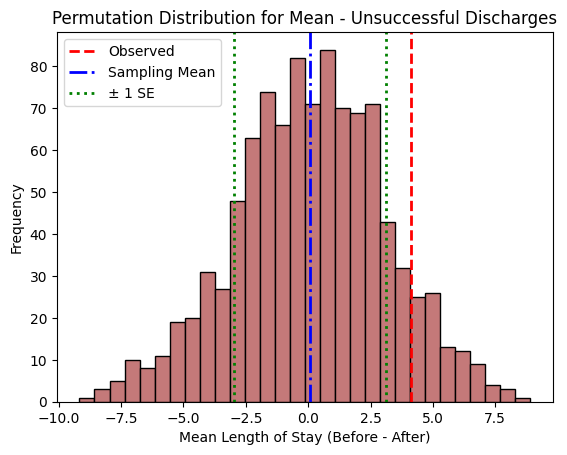

In [18]:
# print observed differences for reference
print(f"Observed Mean Difference for Unsuccessful Discharges (Before - After): {unsuccess_mean_diff:.2f} days")

# calculate p value for unsuccessful discharges
mean_p_value_unsuccess = np.mean(np.abs(permuted_diffs2) >= np.abs(unsuccess_mean_diff))
print(f"P-value: {mean_p_value_unsuccess:.3f}")

# Calculate the mean and standard error from the permuted differences
unsuccess_sampling_mean = np.mean(permuted_diffs2)
unsuccess_standard_error = np.std(permuted_diffs2, ddof=1) 

print(f"Estimated Sampling Mean: {unsuccess_sampling_mean:.2f}")
print(f"Standard Error of the Difference: {unsuccess_standard_error:.2f}")

# Plot the histogram
plt.hist(permuted_diffs2, bins=30, edgecolor='black', color="#C47979")

# Observed Difference
plt.axvline(unsuccess_mean_diff, color='red', linestyle='--', linewidth=2, label='Observed')

# Estimated Sampling Mean
plt.axvline(unsuccess_sampling_mean, color='blue', linestyle='-.', linewidth=2, label='Sampling Mean')

# Standard Error Boundaries
plt.axvline(unsuccess_sampling_mean - unsuccess_standard_error, color='green', linestyle=':', linewidth=2, label='± 1 SE')
plt.axvline(unsuccess_sampling_mean + unsuccess_standard_error, color='green', linestyle=':', linewidth=2)

plt.xlabel('Mean Length of Stay (Before - After)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution for Mean - Unsuccessful Discharges')
plt.legend()
plt.show()

**Analysis for Permutation #2**

 - **Observed Value:** The observed difference is 4.11 days, indicating that the average length of stay for unsuccessful discharges was longer in the before period.

 - **Reference Distribution:** The reference distribution is represented in a histogram showing how frequent the value representing the difference in average length of stay occurs in the permutation. The observed mean difference for successful discharges falls on the right tail of the distribution.

 - **p-value:** The p-value for this permutation test is 0.181, meaning that 18% of the differences between the mean length of stay between the before and after period are as or more extreme than the observed value. The test failed to reject the null hypothesis as 0.181 is not less than 0.05.

**Overall:**
 - Permutation #2 showed that the observed difference in means between the period before and after the re-organization is not statistically significant. According to this test, there is evidence that the average length of stay for unsuccessful discharges has **NOT** changed in the period before and after the re-organization. However, the observed value does not fall within range of the SE of the difference. While the results of this test are not techincally significant, the observed value is more than one standard deviation away from the estimated sample mean. This suggests that there has been a change, but it is not big enough to be significant. 

### Permutation Tests for Median Difference

Observed difference calculation for median:

In [19]:
success_median_before_obs = los[(los['Period'] == 'before re-org') & (los['Discharge_Cat'] == 'successful')]['Length_of_Stay'].median()
success_median_after_obs = los[(los['Period'] == 'after re-org') & (los['Discharge_Cat'] == 'successful')]['Length_of_Stay'].median()
success_median_diff = np.abs(success_median_before_obs - success_median_after_obs)

unsuccess_median_before_obs = los[(los['Period'] == 'before re-org') & (los['Discharge_Cat'] == 'unsuccessful')]['Length_of_Stay'].median()
unsuccess_median_after_obs = los[(los['Period'] == 'after re-org') & (los['Discharge_Cat'] == 'unsuccessful')]['Length_of_Stay'].median()
unsuccess_median_diff = np.abs(unsuccess_median_before_obs - unsuccess_median_after_obs)

print(f"Median Length of Stay for Successful Discharges - Before Re-org: {success_median_before_obs:.0f} days")
print(f"Median Length of Stay for Successful Discharges - After Re-org: {success_median_after_obs:.0f} days")
print(f"Difference in Median Length of Stay for Successful Discharges (Before - After): {success_median_diff:.0f} days")
print(' ')
print(f"Median Length of Stay for Unsuccessful Discharges - Before Re-org: {unsuccess_median_before_obs:.0f} days")
print(f"Median Length of Stay for Unsuccessful Discharges - After Re-org: {unsuccess_median_after_obs:.0f} days")
print(f"Difference in Median Length of Stay for Unsuccessful Discharges (Before - After): {unsuccess_median_diff:.0f} days")

Median Length of Stay for Successful Discharges - Before Re-org: 85 days
Median Length of Stay for Successful Discharges - After Re-org: 91 days
Difference in Median Length of Stay for Successful Discharges (Before - After): 6 days
 
Median Length of Stay for Unsuccessful Discharges - Before Re-org: 14 days
Median Length of Stay for Unsuccessful Discharges - After Re-org: 8 days
Difference in Median Length of Stay for Unsuccessful Discharges (Before - After): 6 days


The following function was built to run the bootstrap confidence interval and the estimated sampling median. Series are created to store the Length of Stay values for each period and discharge type.

In [20]:
def calculate_median_diff_bootstrap(before_data, after_data, n_iterations=1000, random_seed=42):
    """
    Calculates the observed difference (Before - After) between two sample medians
    and estimates the 95% confidence interval using bootstrapping.
    """
    np.random.seed(random_seed)
    n_before = len(before_data)
    n_after = len(after_data)
    
    # Array to store bootstrap differences
    bootstrap_diffs = np.zeros(n_iterations)
    
    for i in range(n_iterations):
        # Sample both groups with replacement independently
        sample_before = np.random.choice(before_data, size=n_before, replace=True)
        sample_after = np.random.choice(after_data, size=n_after, replace=True)
        
        # Calculate the difference in medians for this iteration (BEFORE - AFTER)
        bootstrap_diffs[i] = np.median(sample_before) - np.median(sample_after)
        
    # Calculate the observed difference (BEFORE - AFTER)
    obs_median_diff = np.median(before_data) - np.median(after_data)
    
    # Calculate the 95% Confidence Interval
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    return (obs_median_diff), (ci_lower, ci_upper)

# Isolate the Length of Stay data for successful discharges in both periods
after_successful = los[(los['Period'] == 'after re-org') & (los['Discharge_Cat'] == 'successful')]['Length_of_Stay']
before_successful = los[(los['Period'] == 'before re-org') & (los['Discharge_Cat'] == 'successful')]['Length_of_Stay']

# Isolate the Length of Stay data for unsuccessful discharges in both periods
after_unsuccessful = los[(los['Period'] == 'after re-org') & (los['Discharge_Cat'] == 'unsuccessful')]['Length_of_Stay']
before_unsuccessful = los[(los['Period'] == 'before re-org') & (los['Discharge_Cat'] == 'unsuccessful')]['Length_of_Stay']

#### Permutation #3: Median Difference for Successful Discharges

 - **Null hypothesis:** There is no change in the *median* length of stay for *successful* discharges between the six month period before and after the re-organization
  
 - **Alternative hypothesis:** There is a change in the *median* length of stay for *successful* discharges between the period before and after the re-organization. 
  
 - **Test Statistic:** $$\tilde{x}_{\text{before, successful}} - \tilde{x}_{\text{after, successful}}$$
  
 - **Simulating Data Under the Null:** Period labels are shuffled across unique subjects to maintain exchangeability and avoid inflating Type I errors due to clustered data.

In [21]:
# Permutation test for successful discharges
permuted_diffs3 = [success_median_diff]

for i in range(n_iterations):
    # Shuffle the period labels across unique subjects
    shuffled_periods = np.random.permutation(original_periods)
    subject_to_period = dict(zip(unique_subjects, shuffled_periods))
    
    # Map back to the episode-level dataframe
    los_shuffled = los.copy()
    los_shuffled['Permuted_Period'] = los_shuffled['Subject_ID'].map(subject_to_period)
    
    # Calculate permuted medians for successful discharges
    median_before_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'before re-org') & 
        (los_shuffled['Discharge_Cat'] == 'successful')
        ]['Length_of_Stay'].median()
    
    median_after_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'after re-org') & 
        (los_shuffled['Discharge_Cat'] == 'successful')
        ]['Length_of_Stay'].median()
    
    permuted_diffs3.append(median_before_perm - median_after_perm)

Observed Median Difference for Successful Discharges (Before - After): 6.00 days
P-value: 0.239
Estimated Sampling Median: -0.50
Median Confidence Interval for Successful Discharges: [-13.00, 6.02] days


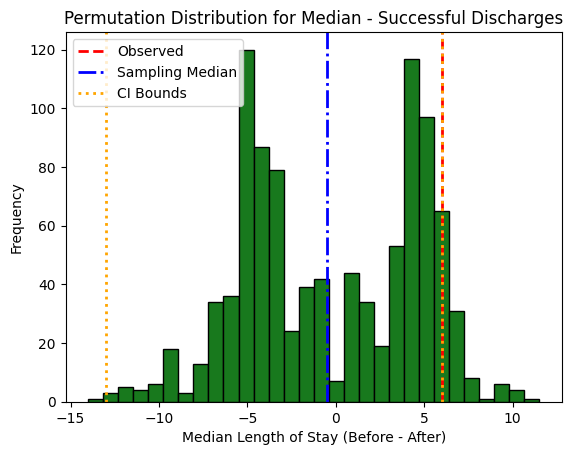

In [22]:
# print observed differences for reference
print(f"Observed Median Difference for Successful Discharges (Before - After): {success_median_diff:.2f} days")

# calculate p value for successful discharges
median_p_value_success = np.mean(np.abs(permuted_diffs3) >= np.abs(success_median_diff))
print(f"P-value: {median_p_value_success:.3f}")

# Estimate the sampling median from the permutation distribution
success_sampling_median = np.median(permuted_diffs3)
print(f"Estimated Sampling Median: {success_sampling_median:.2f}")

# use bootstrap function to calculate confidence interval for the median difference
successful_median_sample_diff, (success_ci_lower, success_ci_upper) = calculate_median_diff_bootstrap(before_successful, after_successful)
print(f"Median Confidence Interval for Successful Discharges: [{success_ci_lower:.2f}, {success_ci_upper:.2f}] days")

# Plot the histogram
plt.hist(permuted_diffs3, bins=30, edgecolor='black', color="#18791D")

# Observed Difference
plt.axvline(success_median_diff, color='red', linestyle='--', linewidth=2, label='Observed')

# Estimated Sampling Median
plt.axvline(success_sampling_median, color='blue', linestyle='-.', linewidth=2, label='Sampling Median')

# Bootstrapped Confidence Interval Boundaries
plt.axvline(success_ci_lower, color='orange', linestyle=':', linewidth=2, label='CI Bounds')
plt.axvline(success_ci_upper, color='orange', linestyle=':', linewidth=2)

plt.xlabel('Median Length of Stay (Before - After)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution for Median - Successful Discharges')
plt.legend()
plt.show()

##### **Analysis for Permutation #3**

 - **Observed Value:** The observed difference is 6 days, indicating that the median length of stay for successful discharges was longer in the before period. 
  
 - **Reference Distribution:** The reference distribution is represented in a histogram showing how frequent the value representing the difference in median length of stay occurs in the permutation. The observed median difference for successful discharges falls on the right tail of the distribution.
  
 - **p-value:** The p-value for this permutation test is 0.239, meaning that 24% of the differences between the median length of stay between the before and after period could be due to chance. The test failed to reject the null hypothesis as 0.239 is not less than 0.05.

**Overall**
 - Permutation #3 showed that the observed difference in median between the period before and after the re-organization is not statistically significant. According to this test, there is evidence that the median length of stay for successful discharges has **NOT** changed in the period before and after the re-organization. However, the observed value falls right in line with the upper bound of the confidence interval. While the p-value indicates that the results are not statistically signficant, the observed value is about 1 STD away from the estimated sample median. Again, this suggests that there has been a change in median length of stay for successful discharges even though it is not a big enough change to be signficant yet. 

#### Permutation #4: Median Difference for Unsuccessful Discharges

 - **Null hypothesis:** There is no change in the *median* length of stay for *unsuccessful* discharges between the six month period before and after the re-organization
  
 - **Alternative hypothesis:** There is a change in the *median* length of stay for *unsuccessful* discharges between the period before and after the re-organization. 
  
 - **Test Statistic:** $$\tilde{x}_{\text{before, unsuccessful}} - \tilde{x}_{\text{after, unsuccessful}}$$
  
 - **Simulating Data Under the Null:** Period labels are shuffled across unique subjects to maintain exchangeability and avoid inflating Type I errors due to clustered data.

In [23]:
# Permutation test for unsuccessful discharges
permuted_diffs4 = [unsuccess_median_diff]

for i in range(n_iterations):
    # Shuffle the period labels across unique subjects
    shuffled_periods = np.random.permutation(original_periods)
    subject_to_period = dict(zip(unique_subjects, shuffled_periods))
    
    # Map back to the episode-level dataframe
    los_shuffled = los.copy()
    los_shuffled['Permuted_Period'] = los_shuffled['Subject_ID'].map(subject_to_period)
    
    # Calculate permuted medians for unsuccessful discharges
    median_before_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'before re-org') & 
        (los_shuffled['Discharge_Cat'] == 'unsuccessful')
        ]['Length_of_Stay'].median()
    
    median_after_perm = los_shuffled[
        (los_shuffled['Permuted_Period'] == 'after re-org') & 
        (los_shuffled['Discharge_Cat'] == 'unsuccessful')
        ]['Length_of_Stay'].median()
    
    permuted_diffs4.append(median_before_perm - median_after_perm)

Observed Median Difference for Unsuccessful Discharges (Before - After): 6.00 days
P-value: 0.223
Estimated Sampling Median: -0.50
Median Confidence Interval for Unsuccessful Discharges: [-2.00, 11.00] days


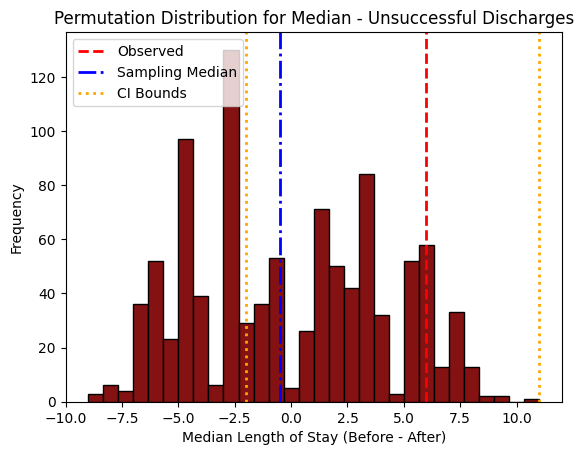

In [24]:
# print observed differences for reference
print(f"Observed Median Difference for Unsuccessful Discharges (Before - After): {unsuccess_median_diff:.2f} days")

# calculate p value for unsuccessful discharges
median_p_value_unsuccess = np.mean(np.abs(permuted_diffs4) >= np.abs(unsuccess_median_diff))
print(f"P-value: {median_p_value_unsuccess:.3f}")

# Estimate the sampling median from the permutation distribution
unsuccess_sampling_median = np.median(permuted_diffs4)
print(f"Estimated Sampling Median: {unsuccess_sampling_median:.2f}")

# use bootstrap function to calculate confidence interval for the median difference
unsuccessful_median_sample_diff, (unsuccess_ci_lower, unsuccess_ci_upper) = calculate_median_diff_bootstrap(before_unsuccessful, after_unsuccessful)
print(f"Median Confidence Interval for Unsuccessful Discharges: [{unsuccess_ci_lower:.2f}, {unsuccess_ci_upper:.2f}] days")

# Plot the histogram
plt.hist(permuted_diffs4, bins=30, edgecolor='black', color="#851212")

# Observed Difference
plt.axvline(unsuccess_median_diff, color='red', linestyle='--', linewidth=2, label='Observed')

# Estimated Sampling Median
plt.axvline(unsuccess_sampling_median, color='blue', linestyle='-.', linewidth=2, label='Sampling Median')

# Bootstrapped Confidence Interval Boundaries
plt.axvline(unsuccess_ci_lower, color='orange', linestyle=':', linewidth=2, label='CI Bounds')
plt.axvline(unsuccess_ci_upper, color='orange', linestyle=':', linewidth=2)

plt.xlabel('Median Length of Stay (Before - After)')
plt.ylabel('Frequency')
plt.title('Permutation Distribution for Median - Unsuccessful Discharges')
plt.legend()
plt.show()

##### **Analysis for Permutation #4**

 - **Observed Vale:** The observed difference is 6 days, indicating that the median length of stay for unsuccessful discharges was longer in the before period.
  
 - **Reference Distribution:** The reference distribution is represented in a histogram showing how frequent the value representing the difference in median length of stay occurs in the permutation. The observed median difference for unsuccessful discharges falls on the right tail of the distribution.
 - **p-value:** The p-value for this permutation test is 0.229, meaning that 23% of the differences between the median length of stay between the before and after period could be due to chance. The test failed to reject the null hypothesis as the p-value is not less than 0.05.

**Overall:**
 - Permutation #4 showed that the observed difference in median between the period before and after the re-organization is not statistically significant. According to this test, there is evidence that the median length of stay for unsuccessful discharges has **NOT** changed in the period before and after the re-organization. The observed value falls within the confidence interval. However, this CI has a wide spread, indicating a high level of variability in this population. This suggests that the observed difference is likely due to noise rather than the re-organization. This also applies to the wide confidence interval seen in permutation #3.